# 1D FDTD Solver: Numerical Dispersion Analysis

In this notebook we analyze the dispersion of the electromagnetic waves simulated by our 1D FDTD solver, that is, their propagation speed. In the finite-difference scheme, the numerical dispersion $c_{\text{num}}$ will be slightly different from the real physical value $c_{0} = 299,\!792,\!458 \,\text{m/s}$. In the Yee scheme, both spatial and temporal derivatives are approximated with second-order centered differences. This leads to a truncation error of order $(\Delta x)^2$, i.e.,

$$|c_\text{num} - c_0| \propto (\Delta x)^2 .$$

In this notebook we verify this relationship by analyzing the propagation of a single Gaussian pulse. We do this as follows:
1. Run the simulation for several values of $\Delta x$
2. Measure $c_\text{num}$ by tracking the pulse peak position over time
3. Plot the relative error $|c_\text{num} - c_0| / c_0$ vs $\Delta x$ on a log-log scale and verify that the slope is 2

We will do this in vacuum, in a dielectric slab, in a magnetic slab, and in a simultaneously dielectric and magnetic slab. Inside a material, the propagation velocity of the waves is affected by the relative permittivity and permeability via

$$c = \frac{c_{0}}{\sqrt{\epsilon_{\mathrm{r}} \mu_{\mathrm{r}}}} .$$

In [17]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from functools import partial

from src.grid import Grid
from src.solver import FDTDSolver1D
from src.sources import SoftSource, gaussian_pulse
from src.boundaries import SimpleABC
from src.output import animate_field
from src.analysis import measure_wave_speed

rc_fonts = {
    "font.family": "serif",
    "font.size"  : 10,
    "mathtext.fontset": "cm",
    "font.serif" : ["CMU Serif"],
    "animation.embed_limit": 50
}
mpl.rcParams.update(rc_fonts)

## Simulation setup

We simulate single Gaussian pulses propagating in the materials of interest. For the nontrivial values of $\epsilon_{\mathrm{r}}$ and $\mu_{\mathrm{r}}$ we will choose $2$. The source is placed near the left edge of the domain so the pulse has the full domain length to propagate before hitting the right boundary.

The pulse width $\sigma$ is chosen to be large enough that the pulse is well-resolved on all grids we test. A pulse that is too narrow relative to $\Delta x$ would introduce additional errors unrelated to dispersion.

We run the same physical scenario for five values of $\Delta x$, keeping the Courant number fixed at $C = 0.5$ so that $\Delta t \propto \Delta x$ and the temporal error scales the same way as the spatial error.

In [18]:
# Physical parameters (fixed across all runs)
L         = 0.5
t_end     = 1.5e-9
courant   = 0.5
t0        = 2e-10
sigma     = 5e-11
amplitude = 1.0

# Grid resolutions to test
dx_values = np.arange(1e-4, 6e-4, 1e-5)
dx_values = [5e-3, 2e-3, 1e-3, 5e-4, 2e-4, 1e-4, 5e-5, 2e-5]

# Material cases to test
materials = [
    {'name': 'Vacuum', 'eps_r': 1.0, 'mu_r': 1.0},
    {'name': 'Dielectric ($\\epsilon_\\mathrm{r}=2$)', 'eps_r': 2.0, 'mu_r': 1.0},
    {'name': 'Magnetic ($\\mu_\\mathrm{r}=2$)', 'eps_r': 1.0, 'mu_r': 2.0},
    {'name': 'Both ($\\epsilon_\\mathrm{r}=\\mu_\\mathrm{r}=2$)','eps_r': 2.0, 'mu_r': 2.0},
]

## Running the simulations

For each combination of material and $\Delta x$ we set up a fresh grid, fill the entire domain with the material, run the simulation, and measure the numerical wave speed. Cases 2 and 3 have the same wave speed ($c_0/\sqrt{2}$) but different 
impedances $\eta = |\mathbf{E}| / |\mathbf{H}| = \sqrt{\mu_0 \mu_\mathrm{r} / \epsilon_0 \epsilon_\mathrm{r}}$, which tests that $\epsilon_\mathrm{r}$ and $\mu_\mathrm{r}$ are handled independently in the update equations.

The ABC `setup()` is called after the material is assigned so that the 
Mur coefficients reflect the correct local wave speed at the boundaries.

In [19]:
c0      = 299792458.0
source_position = 0.05
results = {mat['name']: [] for mat in materials}

for mat in materials:
    print(f"\nMaterial: {mat['name']}")
    c_analytical = c0 / np.sqrt(mat['eps_r'] * mat['mu_r'])
    print(f"Analytical wave speed: {c_analytical:.2f} m/s")
    
    for dx in dx_values:
        grid = Grid(L=L, dx=dx, courant=courant)

        # Fill entire domain with material
        from src.materials import add_material_slab
        add_material_slab(grid, x_start=0.0, x_end=grid.L, eps_r=mat['eps_r'], mu_r=mat['mu_r'])

        wf     = partial(gaussian_pulse, t0=t0, sigma=sigma, amplitude=amplitude)
        source = SoftSource(grid, position=source_position, waveform_func=wf)

        # Setup ABC after material is assigned
        abc = SimpleABC()
        abc.setup(grid)
        solver = FDTDSolver1D(grid, [source], [abc])

        # Run
        n_steps        = round(t_end / grid.dt)
        history_plot   = []

        for n in range(n_steps):
            solver.step(n)
            t = n * grid.dt
            history_plot.append(grid.Ez.copy())

        # Restrict fit to middle 60% of frames
        n_frames    = len(history_plot)
        i_start     = int(0.4 * n_frames)
        i_end       = int(0.8 * n_frames)
        history_fit = history_plot[i_start:i_end]

        c_num, c_err, positions, times = measure_wave_speed(history_fit, grid.dx, grid.dt, x_min=source_position)
        rel_error = abs(c_num - c_analytical) / c_analytical

        results[mat['name']].append({
            'dx'       : dx,
            'c_num'    : c_num,
            'c_err'    : c_err,
            'rel_error': rel_error
        })

        print(f"  dx = {dx*1e3:.2f} mm | c_num = {c_num:.2f} m/s | "
              f"error = {rel_error*100:.4f}% ± {c_err/c_analytical*100:.4f}%")


Material: Vacuum
Analytical wave speed: 299792458.00 m/s
  dx = 5.00 mm | c_num = 296945031.12 m/s | error = 0.9498% ± 0.0066%
  dx = 2.00 mm | c_num = 299287802.10 m/s | error = 0.1683% ± 0.0003%
  dx = 1.00 mm | c_num = 299669664.53 m/s | error = 0.0410% ± 0.0004%
  dx = 0.50 mm | c_num = 299759301.40 m/s | error = 0.0111% ± 0.0004%
  dx = 0.20 mm | c_num = 299784933.68 m/s | error = 0.0025% ± 0.0004%
  dx = 0.10 mm | c_num = 299790441.71 m/s | error = 0.0007% ± 0.0004%
  dx = 0.05 mm | c_num = 299792682.77 m/s | error = 0.0001% ± 0.0004%
  dx = 0.02 mm | c_num = 299791117.54 m/s | error = 0.0004% ± 0.0003%

Material: Dielectric ($\epsilon_\mathrm{r}=2$)
Analytical wave speed: 211985280.00 m/s
  dx = 5.00 mm | c_num = 208365779.19 m/s | error = 1.7074% ± 0.0201%
  dx = 2.00 mm | c_num = 211157699.27 m/s | error = 0.3904% ± 0.0007%
  dx = 1.00 mm | c_num = 211778775.54 m/s | error = 0.0974% ± 0.0003%
  dx = 0.50 mm | c_num = 211932617.04 m/s | error = 0.0248% ± 0.0003%
  dx = 0.20 mm

## Understanding the results

We see that when $\Delta x$ is large, the error is very big. This is because the pulse is not well resolved in the coarsest grids. Firstly, a Gaussian pulse injected at position $x_0$ with temporal width $\sigma$ has a spatial width given by

$$\sigma_x = c_0 \sigma .$$

For our choice of $\sigma = 5 \times 10^{-11} \,\text{s}$ this yields

$$\sigma_x = 3 \times 10^8 \times 5 \times 10^{-11} \approx 0.015 \text{ m}$$

A standard rule of thumb in FDTD is to use at least **10–20 cells per pulse width** (equivalently, per wavelength for a monochromatic wave) to ensure the wave is well-resolved on the grid. The number of cells per pulse width is

$$N_\sigma = \frac{\sigma_x}{\Delta x} = \frac{c_0 \sigma}{\Delta x} .$$

For our set of grid resolutions this gives the following table:

<center>
    
| $\Delta x$ (mm) | $N_\sigma$ | Well resolved? |
| :---: | :---: | :---: |
| 5.0 | 3 | No |
| 2.0 | 7.5 | No |
| 1.0 | 15 | Yes |
| 0.5 | 30 | Yes |
| 0.2 | 75 | Yes |
| 0.1 | 150 | Yes
| 0.05 | 300 | Yes |

</center>

The two coarsest grids violate the cells-per-width criterion, so we expect large dispersion errors for these cases. This is not a failure of the solver but a physically correct consequence of under-resolving the pulse. However, note that the convergence 
plot should still show slope 2 across all resolutions, as the error is supposed to be quadratic in $\Delta x$ in all cases.

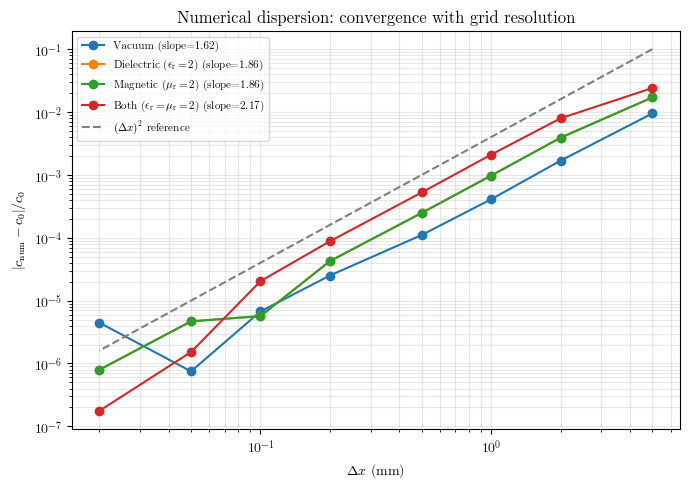

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))

for mat in materials:
    name    = mat['name']
        
    dx_arr  = np.array([r['dx']        for r in results[name]])
    err_arr = np.array([r['rel_error'] for r in results[name]])

    # Fit slope
    slope, intercept = np.polyfit(np.log10(dx_arr), np.log10(err_arr), deg=1)

    ax.loglog(dx_arr * 1e3, err_arr, 'o-', label=f"{name} (slope={slope:.2f})")

# Reference dx^2 line
dx_ref  = np.array([dx_values[0], dx_values[-1]])
err_ref = 1000 * 1e-4 * (dx_ref / dx_ref[0]) ** 2  # Factor of 1000 used to shift the line upwards (fine-tuned)
ax.loglog(dx_ref * 1e3, err_ref, '--', color='gray', label='$(\\Delta x)^2$ reference')

ax.set_xlabel('$\\Delta x$ (mm)')
ax.set_ylabel('$|c_\\mathrm{num} - c_\\mathrm{0}| / c_\\mathrm{0}$')
ax.set_title('Numerical dispersion: convergence with grid resolution')
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/02_dispersion_convergence.png', dpi=600)
plt.show()

## Discussion

Cases 2 (dielectric, $\varepsilon_r = 2$) and 3 (magnetic, $\mu_r = 2$) produce nearly identical errors, as expected from the symmetry of the update equations. This confirms that $\varepsilon_r$ and $\mu_r$ are handled correctly and independently in the solver.

All four material cases converge with slope $\approx 2$ in the decade between $\Delta x = 0.1 \,\text{mm}$ and $\Delta x = 1 \,\text{mm}$, confirming that the Yee scheme is correctly second-order accurate regardless of the medium. Even for $\Delta x = 5 \,\text{mm}$ the line maintains approximately the correct slope, even though the peak is technically not well resolved. 

Interestingly, when $\Delta x$ becomes too small, the results start to deviate. This is the reason why the slope of the blue vacuum curve is $1.62$ according to the fit. Performing more measurements one observes that the error approximately saturates below some vale of $\Delta x$. It could be that for such small spacing we hit the resolution limit of the tracking of the peak, thereby not improving the results. In any case, we see that the FDTD rule of thumb of taking 10–20 cells per pulse width comfortably lands us in the $(\Delta x)^2$ error regime.